In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
import gget
from scipy.stats import zscore

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
import matplotlib.patheffects as path_effects
import matplotlib.ticker as mtick

import textwrap
import matplotlib.patches as patches

from matplotlib.patches import Patch
import matplotlib.ticker as ticker

sc.settings.verbosity = 2

# Load data

In [2]:
%%time
# fpath = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups.h5ad"
fpath = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups_v2.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 695 ms, sys: 2.28 s, total: 2.97 s
Wall time: 7.77 s


AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

In [3]:
adata = adata[adata.obs['pooled_condition'].isin(['Control', 'mmMYOD1']), :].copy()
adata

AnnData object with n_obs × n_vars = 9157 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std

In [4]:
adata.X = adata.layers['raw_counts']

sc.pp.filter_genes(adata, min_counts=10)

sc.pp.normalize_total(adata, target_sum=1e4)

sc.pp.log1p(adata)
adata.layers['log_norm'] = adata.X.copy()

adata

filtered out 2091 genes that are detected in less than 10 counts
normalizing counts per cell
    finished (0:00:01)


AnnData object with n_obs × n_vars = 9157 × 23035
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'std

# Tomaru et al. TFs

In [9]:
fib_tfs = [
    'TWIST2', 'TWIST1', 'LHX9', 'MKX', 'PRRX1', 'PRRX2', 'MSX1', 'OSR1', 'CITED2', 
    'RUNX1T1', 'FOXD1', 'TBX3', 'NFIX', 'HOXB5', 'HOXC8', 'MEIS2', 'HOXC6', 'HOXC4',
]

print(len(fib_tfs))

fib_tfs = [g for g in fib_tfs if g in adata.var_names]
print(len(fib_tfs))
print(", ".join(sorted(fib_tfs))) # HOXB5 missing

18
17
CITED2, FOXD1, HOXC4, HOXC6, HOXC8, LHX9, MEIS2, MKX, MSX1, NFIX, OSR1, PRRX1, PRRX2, RUNX1T1, TBX3, TWIST1, TWIST2


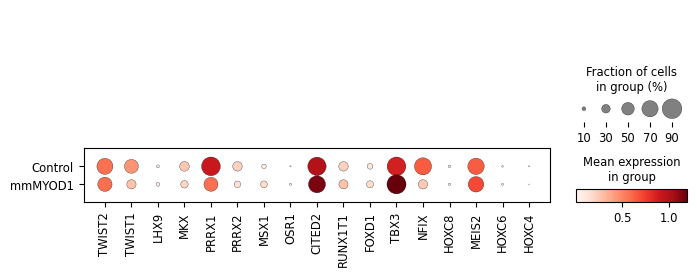

In [11]:
sc.pl.dotplot(
    adata,
    var_names=fib_tfs,
    groupby='pooled_condition',
    layer='log_norm',
    # standard_scale='var',
)

In [ ]:
# get top expressed TFs in controls
# quantify DE

# Get top expressed TFs

In [9]:
path = "../../resources/HumanTF_v_1.01.csv"

df = pd.read_csv(path)
print(df.shape)

df = df[df['Is TF?'] == 'Yes']
print(df.shape)

tf_list = df['HGNC symbol'].dropna().unique().tolist()
print(len(tf_list))

tf_list[:5]

(2765, 29)
(1639, 29)
1639


['TFAP2A', 'TFAP2B', 'TFAP2C', 'TFAP2D', 'TFAP2E']

In [23]:
cdata = adata[adata.obs['pooled_condition'] == 'Control', :].copy()

# re=normalize
cdata.X = cdata.layers['raw_counts']
sc.pp.filter_genes(cdata, min_counts=10)
sc.pp.normalize_total(cdata, target_sum=1e4)
sc.pp.log1p(cdata)
cdata.layers['log_norm'] = cdata.X.copy()

func = 'mean'

# pseudobulk
aggdata = sc.get.aggregate(
    cdata,
    by='pooled_condition',
    func=func,
    layer='log_norm',
)

aggdata.X = aggdata.layers[func]

X = aggdata.X if isinstance(aggdata.X, np.ndarray) else aggdata.X.toarray()
df = pd.DataFrame(X, index=aggdata.obs_names, columns=aggdata.var_names).T
df = df.reset_index()
print(df.shape)
df.head()


df = df[df['gene_name'].isin(tf_list)].copy()
print(df.shape)

df = df.sort_values(by='Control', ascending=False)
df = df.reset_index(drop=True)

df.head(15)

filtered out 3074 genes that are detected in less than 10 counts
normalizing counts per cell
    finished (0:00:00)
(19961, 2)
(1247, 2)


,gene_name,Control
0,NME2,2.695490
1,STAT1,2.242741
2,DRAP1,1.863246
3,YBX1,1.568044
4,SP100,1.447824
5,SON,1.416436
6,HIF1A,1.355213
7,PLSCR1,1.340421
8,ARID5B,1.282772
9,PA2G4,1.241943


In [ ]:
# # extract top expressed Fib genes from control group
# n_genes = 15

# cdata = adata[adata.obs['pooled_condition'] == 'Control', :].copy()
# print(cdata.shape)

# tf_subset = [g for g in tf_list if g in cdata.var_names]

# cdata.X = cdata.layers['log_norm']

# mean_expr = cdata[:, tf_subset].X.mean(axis=0).A1  
# top_tfs = [tf_subset[i] for i in mean_expr.argsort()[::-1][:n_genes]]

# print(len(top_tfs))
# top_tfs

In [24]:
df.head()

,gene_name,Control
0,NME2,2.695490
1,STAT1,2.242741
2,DRAP1,1.863246
3,YBX1,1.568044
4,SP100,1.447824


In [25]:
df[df['gene_name'] == 'PRRX1']

,gene_name,Control
16,PRRX1,0.902922


In [26]:
# where do fib TFs call in this list?
fib_tfs = [
    'TWIST2', 'TWIST1', 'LHX9', 'MKX', 'PRRX1', 'PRRX2', 'MSX1', 'OSR1', 'CITED2', 
    'RUNX1T1', 'FOXD1', 'TBX3', 'NFIX', 'HOXB5', 'HOXC8', 'MEIS2', 'HOXC6', 'HOXC4',
]


fdf = df[df['gene_name'].isin(fib_tfs)].copy()
print(fdf.shape)
display(fdf)

(15, 2)


,gene_name,Control
16,PRRX1,0.902922
17,TBX3,0.867513
42,NFIX,0.638077
43,MEIS2,0.637371
54,TWIST2,0.572548
68,TWIST1,0.438625
141,MKX,0.253208
171,PRRX2,0.215909
373,FOXD1,0.096722
475,MSX1,0.071640


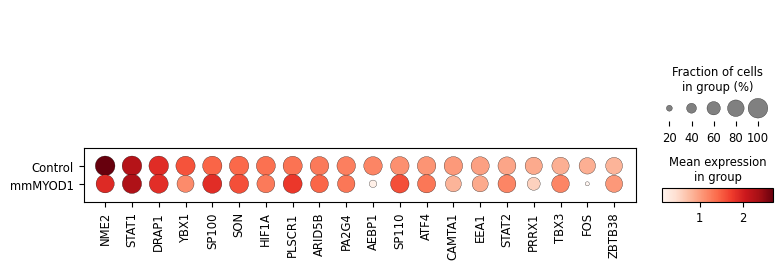

In [32]:
n_top_tfs = 20

gene_list = df.head(n_top_tfs)['gene_name'].tolist()

plt.rcdefaults()

sc.pl.dotplot(
    adata,
    var_names=gene_list,
    groupby='pooled_condition',
    layer='log_norm',
    # standard_scale='var',
)

# DEG

In [33]:
sc.tl.rank_genes_groups(
    adata,
    groupby='pooled_condition',
    use_raw=False,
    layer='log_norm',
    method='wilcoxon',
    pts=True,
)

deg = sc.get.rank_genes_groups_df(
    adata,
    group=None,
)

print(deg.shape)
deg.head()

ranking genes
    finished (0:00:17)
(46070, 8)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,Control,MT-ATP8,71.380737,4.185438,0.0,0.0,1.000000,0.787140
1,Control,MT-ND4L,71.080276,5.370659,0.0,0.0,0.997972,0.350333
2,Control,COL1A1,68.791817,3.176288,0.0,0.0,1.000000,0.880266
3,Control,MT-ND2,68.765785,1.965367,0.0,0.0,1.000000,0.983592
4,Control,CST3,68.728851,3.109654,0.0,0.0,0.999131,0.603548


In [45]:
deg['is_tf'] = deg['names'].isin(tf_list)

sig = deg[deg['pvals_adj'] < 0.05].copy()

sig = sig[sig['is_tf']]

print(sig.shape)
sig.head(10)

(1468, 9)


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,is_tf
43,Control,AEBP1,58.189075,3.308769,0.000000e+00,0.000000e+00,0.920892,0.274501,True
84,Control,NME2,49.047543,1.302877,0.000000e+00,0.000000e+00,0.999855,0.901996,True
87,Control,FOS,48.442070,3.350065,0.000000e+00,0.000000e+00,0.790930,0.124612,True
233,Control,NFIX,32.880119,1.645338,4.228966e-237,2.848369e-235,0.747899,0.333038,True
285,Control,EPAS1,30.096132,1.362033,5.444318e-199,2.830922e-197,0.805564,0.424834,True
302,Control,PBX1,29.267057,1.471275,2.724464e-188,1.307459e-186,0.745001,0.361419,True
319,Control,HES1,28.727037,1.989634,1.753685e-181,7.905308e-180,0.558099,0.143237,True
344,Control,YBX1,27.590185,0.832423,1.459378e-167,6.057077e-166,0.972037,0.828381,True
354,Control,FOSB,27.290234,3.738975,5.539425e-164,2.230781e-162,0.413793,0.027938,True
495,Control,PRRX1,22.389339,0.902543,4.999483e-111,1.295423e-109,0.843958,0.573836,True


In [49]:
top_deg_tfs = sig.head(20)['names'].tolist()


fib_tfs = [
    'TWIST2', 'TWIST1', 'LHX9', 'MKX', 'PRRX1', 'PRRX2', 'MSX1', 'OSR1', 'CITED2', 
    'RUNX1T1', 'FOXD1', 'TBX3', 'NFIX', 'HOXB5', 'HOXC8', 'MEIS2', 'HOXC6', 'HOXC4',
]

fib_tfs = [g for g in fib_tfs if g in adata.var_names]

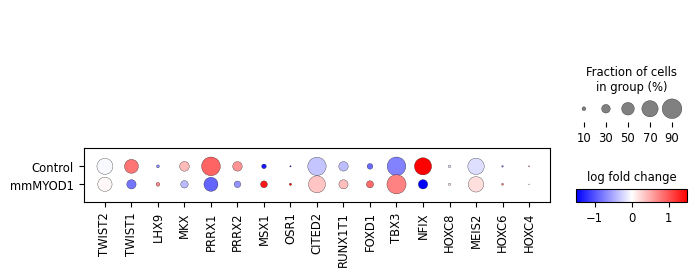

In [51]:
sc.pl.rank_genes_groups_dotplot(
    adata,
    groupby='pooled_condition',
    var_names=fib_tfs, 
    values_to_plot='logfoldchanges',
    cmap='bwr',
    vcenter=0,
    vmax=1.5,
    vmin=-1.5,
)
